In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from sklearn.model_selection import RandomizedSearchCV

from sklearn.cluster import BisectingKMeans

import pickle

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
with open("/kaggle/input/tokens/tokens.pkl", "rb") as f:
    data = pickle.load(f)

print(data["headlines_tokens"][:10])   
print(data["categories"][:5])          

['family', 'generation', 'changer', 'firestorm', 'aol', 'employee', 'benefit', 'cut', 'dakota', 'access']
['IMPACT', 'BUSINESS', 'POLITICS', 'GREEN', 'SCIENCE']


## Models Implementation

## KMeans 

In [4]:
def combine(data):
    articles = []
    for headline_tokens, desc_tokens in zip(data["headlines_tokens"], data["description_tokens"]):

        headline = " ".join(headline_tokens.split())
        description = " ".join(desc_tokens.split())

        articles.append(headline + " " + description)
    return articles


In [5]:
articles = combine(data)

In [6]:
pipeline_2 = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True, 
        stop_words="english", 
        ngram_range=(1,2), 
        max_df=0.05, 
        min_df=50, 
        max_features=10000)),
    ('svd', TruncatedSVD(n_components=50, random_state=22)),
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=27, random_state=22))
])

In [7]:
pipeline_2.fit(articles)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.05, max_features=10000, min_df=50,
                                 ngram_range=(1, 2), stop_words='english')),
                ('svd', TruncatedSVD(n_components=50, random_state=22)),
                ('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=27, random_state=22))])

In [8]:
labels = pipeline_2.predict(articles[:20]) 
print (labels)

[ 0  0 15  0  0  0  0 23  0 15  0  0  0  0  0  0 24  0  0  0]


In [9]:
# get cluster labels
labels_tuned_2 = pipeline_2.named_steps['kmeans'].labels_  

# get features
X_reduced_tfidf_2 = pipeline_2.named_steps['svd'].transform( pipeline_2.named_steps['tfidf'].transform(articles) )

In [10]:
print("Silhouette_tuned:", silhouette_score(X_reduced_tfidf_2, labels_tuned_2)) 
print("Calinski-Harabasz_tuned:", calinski_harabasz_score(X_reduced_tfidf_2, labels_tuned_2))
print("Davies–Bouldin Index_tuned:", davies_bouldin_score(X_reduced_tfidf_2, labels_tuned_2))

Silhouette_tuned: 0.8002584353438429
Calinski-Harabasz_tuned: 2802.05453771459
Davies–Bouldin Index_tuned: 0.31557931024050867


In [11]:
preprocessor2 = Pipeline(pipeline_2.steps[:-1])
processed_data2 = preprocessor2.transform(articles)

labels2 = pipeline_2.named_steps['kmeans'].labels_

pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(processed_data2)

df_pca_2 = pd.DataFrame(pca_2d, columns=['PC1', 'PC2'])
df_pca_2['Cluster'] = labels2.astype(str) 

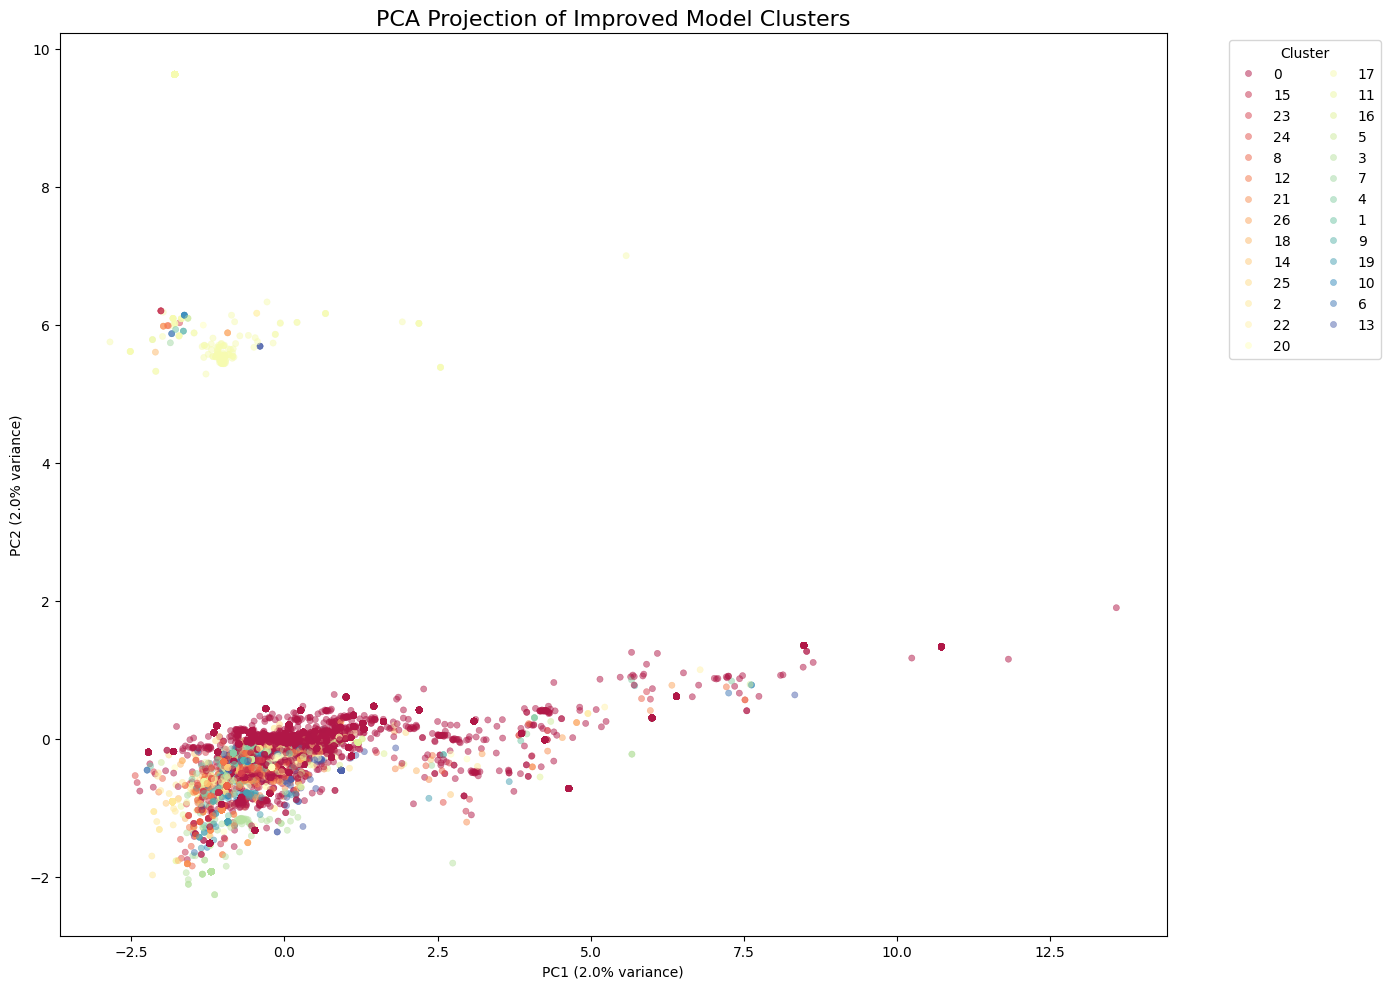

In [12]:
 
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca_2,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Spectral',
    alpha=0.5,
    s=20,
    edgecolor=None
)

plt.title("PCA Projection of Improved Model Clusters", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()

plt.savefig("clusters_tunedkmeans.png", dpi=300)
plt.show()


## BisectingKMeans

In [ ]:
pipeline_bisecting = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=0.02, min_df=20, stop_words='english')),
    ('svd', TruncatedSVD(n_components=100)),
    ('scaler', StandardScaler()),
    ('kmeans', BisectingKMeans(n_clusters=27, random_state=22)) 
])

In [14]:
pipeline_bisecting.fit(articles)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.02, min_df=20, stop_words='english')),
                ('svd', TruncatedSVD(n_components=100)),
                ('scaler', StandardScaler()),
                ('kmeans', BisectingKMeans(n_clusters=27, random_state=22))])

In [15]:
print(pd.Series(pipeline_bisecting.named_steps['kmeans'].labels_).value_counts())

15    39958
18     1866
19     1710
20     1693
2      1264
12     1070
10      866
3       822
11      774
7       603
5       412
16      387
25      382
1       338
8       338
13      275
23      242
4       237
0       207
9       143
6       110
22      108
17      103
21      102
24       95
26       95
14       75
Name: count, dtype: int64


In [16]:
preprocessor3 = Pipeline(pipeline_bisecting.steps[:-1])
processed_data3 = preprocessor3.transform(articles)

labels3 = pipeline_bisecting.named_steps['kmeans'].labels_

pca = PCA(n_components=2, random_state=42)
pca_2d_3 = pca.fit_transform(processed_data3)

df_pca_3 = pd.DataFrame(pca_2d_3, columns=['PC1', 'PC2'])
df_pca_3['Cluster'] = labels3.astype(str) 

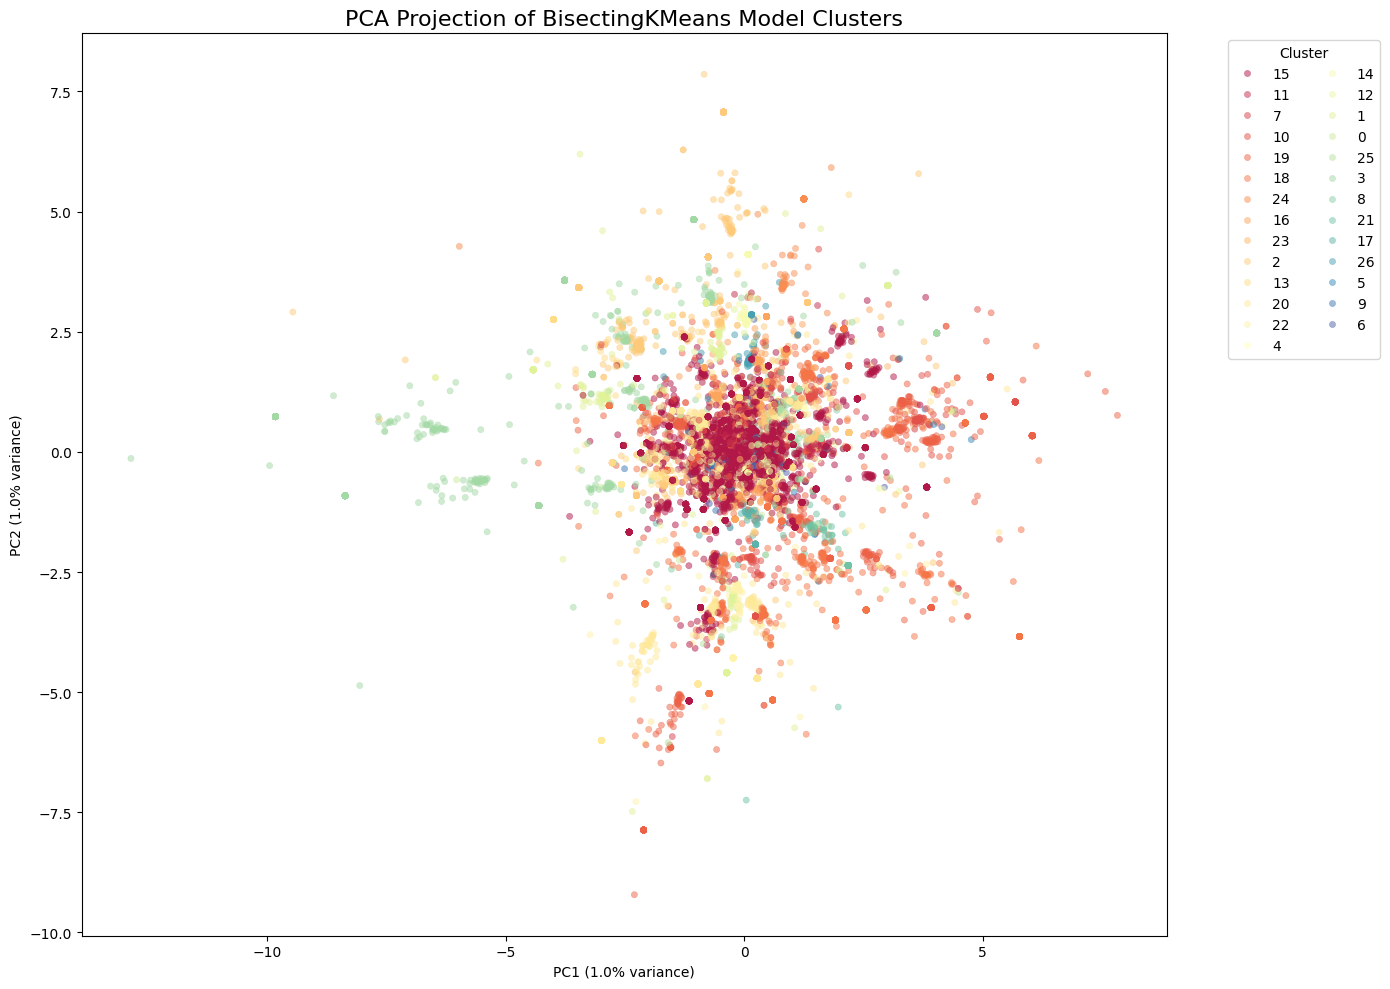

In [17]:
 
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca_3,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Spectral',
    alpha=0.5,
    s=20,
    edgecolor=None
)

plt.title("PCA Projection of BisectingKMeans Model Clusters", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()

plt.savefig("clusters_bisectingkmeans.png", dpi=300)
plt.show()


## Topic Meaning Check

In [18]:
def get_bisecting_summary(pipeline, n_words=8):
    tfidf = pipeline.named_steps['tfidf']
    feature_names = tfidf.get_feature_names_out()
    
    kmeans = pipeline.named_steps['kmeans']
    centroids = kmeans.cluster_centers_
    
    svd = pipeline.named_steps['svd'].components_
    
    word_weights = centroids @ svd

    print(f"{'Cluster':<12} | {'Top Terms'}")
    print("-" * 60)

    for i, weights in enumerate(word_weights):
        # Find the indices of the highest weights
        top_indices = weights.argsort()[-n_words:][::-1]
        top_words = [feature_names[idx] for idx in top_indices]
        print(f"Cluster {i:<10} | {', '.join(top_words)}")

get_bisecting_summary(pipeline_bisecting)

Cluster      | Top Terms
------------------------------------------------------------
Cluster 0          | need, idea, tell, fashion, learned, student, attack, loss
Cluster 1          | watch, reason, obama, cancer, tip, game, mean, body
Cluster 2          | im, climate, place, style, question, mean, face, death
Cluster 3          | million, mom, talk, report, story, doesnt, making, war
Cluster 4          | thing, fight, night, board, parent, way, fashion, social
Cluster 5          | day, relationship, body, social, run, got, king, road
Cluster 6          | food, job, list, huffpost, doesnt, got, tip, student
Cluster 7          | way, woman, body, huffpost, didnt, moment, loss, leader
Cluster 8          | people, hotel, red, key, weight, beauty, person, ceo
Cluster 9          | change, didnt, ago, level, hillary, living, wrong, point
Cluster 10         | world, week, house, white, study, police, power, idea
Cluster 11         | new, 10, wedding, student, leader, body, set, road
Cluster

In [19]:
# get cluster labels
labels_tuned_3 = pipeline_bisecting.named_steps['kmeans'].labels_  

# get features
X_reduced_tfidf_3 = pipeline_bisecting.named_steps['svd'].transform( pipeline_bisecting.named_steps['tfidf'].transform(articles) )

In [20]:
print("Silhouette_tuned:", silhouette_score(X_reduced_tfidf_3, labels_tuned_3)) 
print("Calinski-Harabasz_tuned:", calinski_harabasz_score(X_reduced_tfidf_3, labels_tuned_3))
print("Davies–Bouldin Index_tuned:", davies_bouldin_score(X_reduced_tfidf_3, labels_tuned_3))

Silhouette_tuned: 0.406498710909789
Calinski-Harabasz_tuned: 679.3936733431606
Davies–Bouldin Index_tuned: 2.3442570637483313


# Models Comparison

In [21]:
data = {
    "Metric": ["Silhouette Score", "Calinski-Harabasz", "Davies–Bouldin Index"],
    "Baseline": [0.55440797, 1227.805626, 0.64311878],
    "Tuned": [0.78324031, 2979.168284, 0.47069317],
    "Improved Tuned" :[0.8002584353438429, 2802.05453771459, 0.31557931024050867],
    "BiKmeans": [0.5624054765974101, 620.7895988434705, 2.3955632266765683]
}
metrics_df = pd.DataFrame(data)
print("### Model Performance Comparison ###")
print(metrics_df.to_string(index=False))

### Model Performance Comparison ###
              Metric    Baseline       Tuned  Improved Tuned   BiKmeans
    Silhouette Score    0.554408    0.783240        0.800258   0.562405
   Calinski-Harabasz 1227.805626 2979.168284     2802.054538 620.789599
Davies–Bouldin Index    0.643119    0.470693        0.315579   2.395563
